# Threshold Sweep — SankofaWatch Mining Detection
Evaluates all 5 trained models across a range of probability thresholds on the **test split**.
Output: Precision-Recall curves, F1 vs Threshold, IoU vs Threshold, and a final recommendation.

In [ ]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'segmentation-models-pytorch'], check=True)

import torch
import segmentation_models_pytorch as smp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import os, json, warnings
warnings.filterwarnings('ignore')
print('Packages ready')

Packages ready


## Configuration — same paths as training notebook

In [ ]:
LOCAL_DATA   = '/content/optical_training_data'
LOCAL_MODELS = '/content/mining_models_6bands'

BUCKET_BASE   = 'gs://mcnobert-optical-data/optical_training_data'
BUCKET_MODELS = 'gs://mcnobert-optical-data/mining_models_6bands'
BUCKET_RESULTS = 'gs://mcnobert-optical-data/threshold_sweep_results'

SELECTED_BANDS = [2, 3, 7, 10, 11, 19]   # GREEN, RED, NIR, SWIR1, SWIR2, BSI
DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'

# Thresholds to sweep
THRESHOLDS = [round(t, 2) for t in np.arange(0.10, 0.75, 0.05)]

MODEL_FILES = [
    ('best_iou_model_6band.pth',              'Best IoU'),
    ('best_precision_model_6band.pth',         'Best Precision'),     # <-- production model
    ('best_recall_model_6band.pth',            'Best Recall'),
    ('best_precision_recall_model_6band.pth',  'Best F1'),
    ('best_iou_recall_model_6band.pth',        'Best IoU+Recall'),
]

print(f'Device: {DEVICE}')
print(f'Thresholds: {THRESHOLDS}')

Device: cuda
Thresholds: [np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7)]


## Download data and models from GCS

In [ ]:
os.makedirs(LOCAL_DATA,   exist_ok=True)
os.makedirs(LOCAL_MODELS, exist_ok=True)

print('Downloading test data...')
subprocess.run(['gsutil', '-m', 'cp', '-rn', BUCKET_BASE, '/content/'], check=True)

print('Downloading models...')
subprocess.run(['gsutil', '-m', 'cp', '-rn', BUCKET_MODELS + '/*', LOCAL_MODELS + '/'], check=True)

# Count test samples
test_images = list((Path(LOCAL_DATA) / 'test' / 'images').glob('*.npy'))
print(f'Test samples: {len(test_images)}')

Test samples: 1434


## Dataset — same as training notebook

In [ ]:
def extract_number(filename):
    """Extract number from filename — works for patch_001, negative_patch_001, etc."""
    for part in reversed(filename.stem.split('_')):
        try:
            return int(part)
        except ValueError:
            continue
    return 0


class OpticalMiningDataset(Dataset):
    def __init__(self, data_dir, split='test', selected_bands=None):
        self.data_dir       = Path(data_dir)
        self.split          = split
        self.selected_bands = selected_bands or list(range(22))
        self.image_dir      = self.data_dir / split / 'images'
        self.mask_dir       = self.data_dir / split / 'masks'

        all_image_files = list(self.image_dir.glob('*.npy'))
        all_mask_files  = list(self.mask_dir.glob('*.npy'))

        # Filter out duplicates (files with parentheses in name)
        image_files = [f for f in all_image_files if '(' not in f.name]
        mask_files  = [f for f in all_mask_files  if '(' not in f.name]

        # Match by numeric ID — same approach as training notebook
        image_dict  = {extract_number(f): f for f in image_files}
        mask_dict   = {extract_number(f): f for f in mask_files}
        common_ids  = sorted(set(image_dict.keys()) & set(mask_dict.keys()))

        self.image_files = [image_dict[i] for i in common_ids]
        self.mask_files  = [mask_dict[i]  for i in common_ids]

        print(f'{split} split: {len(self.image_files)} matched pairs')

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = np.load(self.image_files[idx]).astype(np.float32)
        mask  = np.load(self.mask_files[idx]).astype(np.float32)
        image = image[:, :, self.selected_bands]
        # Normalize same as training
        norm = np.zeros_like(image)
        for b in range(image.shape[2]):
            band = image[:, :, b]
            valid = band[np.isfinite(band)]
            if len(valid) > 10:
                p2, p98 = np.percentile(valid, [2, 98])
                norm[:, :, b] = np.clip((band - p2) / (p98 - p2 + 1e-8), 0, 1)
            else:
                norm[:, :, b] = 0.5
        tensor = torch.from_numpy(norm).permute(2, 0, 1)   # C, H, W
        mask_t = torch.from_numpy(mask).unsqueeze(0)        # 1, H, W
        return tensor, mask_t


test_dataset = OpticalMiningDataset(LOCAL_DATA, split='test', selected_bands=SELECTED_BANDS)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)

test split: 1434 matched pairs


## Sweep function

In [ ]:
def load_model(model_path, device):
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model = smp.FPN(
        encoder_name='resnet50',
        encoder_weights=None,
        in_channels=6,
        classes=1,
        activation=None
    ).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model


def collect_probabilities(model, loader, device):
    """Run inference once and collect all probabilities + ground truth masks."""
    all_probs = []
    all_masks = []
    with torch.no_grad():
        for images, masks in tqdm(loader, desc='Inference', leave=False):
            images = images.to(device)
            logits = model(images)
            probs  = torch.sigmoid(logits).cpu().numpy()   # (B, 1, H, W)
            all_probs.append(probs)
            all_masks.append(masks.numpy())
    return np.concatenate(all_probs, axis=0), np.concatenate(all_masks, axis=0)


def metrics_at_threshold(probs, masks, threshold):
    """Compute pixel-level precision, recall, F1, IoU, accuracy at a given threshold."""
    preds = (probs >= threshold).astype(np.uint8)
    gt    = (masks >= 0.5).astype(np.uint8)

    tp = int((preds * gt).sum())
    fp = int((preds * (1 - gt)).sum())
    fn = int(((1 - preds) * gt).sum())
    tn = int(((1 - preds) * (1 - gt)).sum())

    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    iou       = tp / (tp + fp + fn + 1e-8)
    accuracy  = (tp + tn) / (tp + tn + fp + fn + 1e-8)

    return {
        'threshold': threshold,
        'precision': round(precision, 4),
        'recall':    round(recall, 4),
        'f1':        round(f1, 4),
        'iou':       round(iou, 4),
        'accuracy':  round(accuracy, 4),
    }


print('Functions ready')

Functions ready


## Run the sweep across all models

In [ ]:
device = torch.device(DEVICE)
all_sweep_results = {}   # model_name -> list of metric dicts

for model_file, model_name in MODEL_FILES:
    model_path = Path(LOCAL_MODELS) / model_file
    if not model_path.exists():
        print(f'SKIP {model_name} — file not found')
        continue

    print(f'\n{model_name}')
    model = load_model(model_path, device)

    # Run inference ONCE — reuse probabilities for all thresholds
    probs, masks = collect_probabilities(model, test_loader, device)
    print(f'  Probability range: [{probs.min():.3f}, {probs.max():.3f}]')

    results = []
    for t in THRESHOLDS:
        m = metrics_at_threshold(probs, masks, t)
        results.append(m)
        print(f'  t={t:.2f}  P={m["precision"]:.3f}  R={m["recall"]:.3f}  F1={m["f1"]:.3f}  IoU={m["iou"]:.3f}')

    all_sweep_results[model_name] = results
    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

print('\nSweep complete.')


Best IoU


  Probability range: [0.000, 1.000]
  t=0.10  P=0.602  R=0.908  F1=0.724  IoU=0.567
  t=0.15  P=0.624  R=0.891  F1=0.734  IoU=0.580
  t=0.20  P=0.642  R=0.877  F1=0.741  IoU=0.589
  t=0.25  P=0.656  R=0.864  F1=0.746  IoU=0.595
  t=0.30  P=0.669  R=0.851  F1=0.749  IoU=0.599
  t=0.35  P=0.681  R=0.838  F1=0.751  IoU=0.602
  t=0.40  P=0.692  R=0.826  F1=0.753  IoU=0.604
  t=0.45  P=0.702  R=0.813  F1=0.753  IoU=0.604
  t=0.50  P=0.713  R=0.799  F1=0.753  IoU=0.604
  t=0.55  P=0.723  R=0.784  F1=0.752  IoU=0.603
  t=0.60  P=0.733  R=0.769  F1=0.751  IoU=0.601
  t=0.65  P=0.744  R=0.751  F1=0.748  IoU=0.597
  t=0.70  P=0.756  R=0.731  F1=0.743  IoU=0.591

Best Precision


  Probability range: [0.000, 1.000]
  t=0.10  P=0.611  R=0.898  F1=0.727  IoU=0.572
  t=0.15  P=0.634  R=0.880  F1=0.737  IoU=0.583
  t=0.20  P=0.651  R=0.864  F1=0.743  IoU=0.591
  t=0.25  P=0.666  R=0.850  F1=0.747  IoU=0.596
  t=0.30  P=0.679  R=0.836  F1=0.749  IoU=0.599
  t=0.35  P=0.690  R=0.822  F1=0.750  IoU=0.601
  t=0.40  P=0.701  R=0.808  F1=0.751  IoU=0.601
  t=0.45  P=0.712  R=0.795  F1=0.751  IoU=0.601
  t=0.50  P=0.722  R=0.780  F1=0.750  IoU=0.600
  t=0.55  P=0.732  R=0.764  F1=0.748  IoU=0.597
  t=0.60  P=0.743  R=0.748  F1=0.745  IoU=0.594
  t=0.65  P=0.753  R=0.729  F1=0.741  IoU=0.588
  t=0.70  P=0.765  R=0.707  F1=0.735  IoU=0.581

Best Recall


  Probability range: [0.000, 1.000]
  t=0.10  P=0.545  R=0.920  F1=0.684  IoU=0.520
  t=0.15  P=0.566  R=0.905  F1=0.697  IoU=0.535
  t=0.20  P=0.583  R=0.892  F1=0.705  IoU=0.545
  t=0.25  P=0.598  R=0.880  F1=0.712  IoU=0.553
  t=0.30  P=0.610  R=0.869  F1=0.717  IoU=0.559
  t=0.35  P=0.622  R=0.857  F1=0.721  IoU=0.564
  t=0.40  P=0.633  R=0.846  F1=0.724  IoU=0.568
  t=0.45  P=0.644  R=0.834  F1=0.727  IoU=0.571
  t=0.50  P=0.655  R=0.821  F1=0.729  IoU=0.573
  t=0.55  P=0.666  R=0.808  F1=0.730  IoU=0.575
  t=0.60  P=0.677  R=0.793  F1=0.730  IoU=0.575
  t=0.65  P=0.689  R=0.777  F1=0.730  IoU=0.575
  t=0.70  P=0.702  R=0.758  F1=0.729  IoU=0.573

Best F1


  Probability range: [0.000, 1.000]
  t=0.10  P=0.602  R=0.908  F1=0.724  IoU=0.567
  t=0.15  P=0.624  R=0.891  F1=0.734  IoU=0.580
  t=0.20  P=0.642  R=0.877  F1=0.741  IoU=0.589
  t=0.25  P=0.656  R=0.864  F1=0.746  IoU=0.595
  t=0.30  P=0.669  R=0.851  F1=0.749  IoU=0.599
  t=0.35  P=0.681  R=0.838  F1=0.751  IoU=0.602
  t=0.40  P=0.692  R=0.826  F1=0.753  IoU=0.604
  t=0.45  P=0.702  R=0.813  F1=0.753  IoU=0.604
  t=0.50  P=0.713  R=0.799  F1=0.753  IoU=0.604
  t=0.55  P=0.723  R=0.784  F1=0.752  IoU=0.603
  t=0.60  P=0.733  R=0.769  F1=0.751  IoU=0.601
  t=0.65  P=0.744  R=0.751  F1=0.748  IoU=0.597
  t=0.70  P=0.756  R=0.731  F1=0.743  IoU=0.591

Best IoU+Recall


  Probability range: [0.000, 1.000]
  t=0.10  P=0.600  R=0.909  F1=0.723  IoU=0.566
  t=0.15  P=0.622  R=0.892  F1=0.733  IoU=0.579
  t=0.20  P=0.639  R=0.878  F1=0.740  IoU=0.587
  t=0.25  P=0.654  R=0.865  F1=0.745  IoU=0.594
  t=0.30  P=0.667  R=0.853  F1=0.748  IoU=0.598
  t=0.35  P=0.678  R=0.840  F1=0.751  IoU=0.601
  t=0.40  P=0.689  R=0.828  F1=0.752  IoU=0.603
  t=0.45  P=0.700  R=0.815  F1=0.753  IoU=0.604
  t=0.50  P=0.710  R=0.801  F1=0.753  IoU=0.604
  t=0.55  P=0.721  R=0.787  F1=0.752  IoU=0.603
  t=0.60  P=0.731  R=0.771  F1=0.751  IoU=0.601
  t=0.65  P=0.742  R=0.754  F1=0.748  IoU=0.597
  t=0.70  P=0.753  R=0.734  F1=0.743  IoU=0.592

Sweep complete.


## Plots

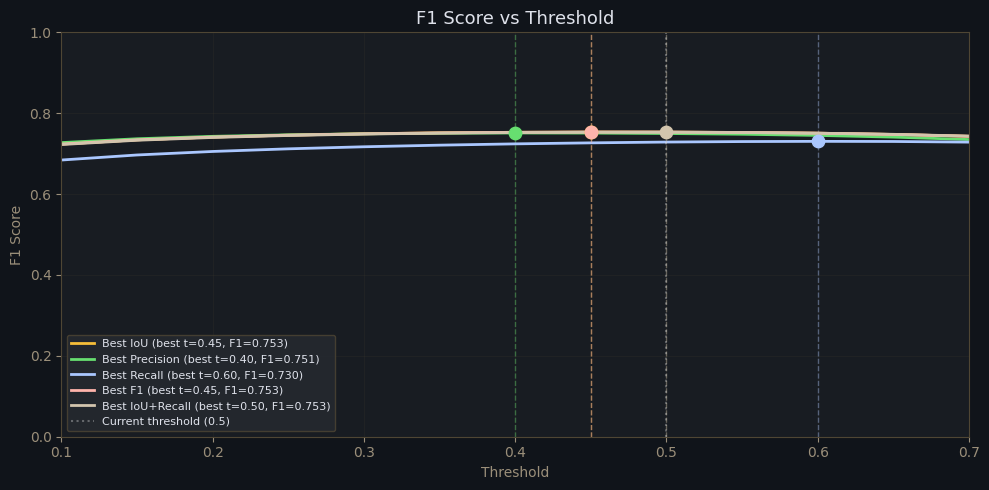

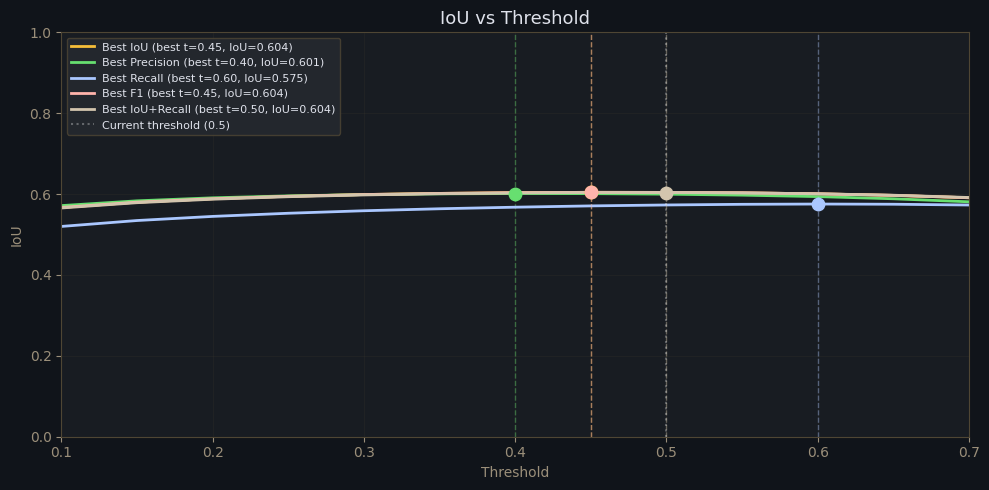

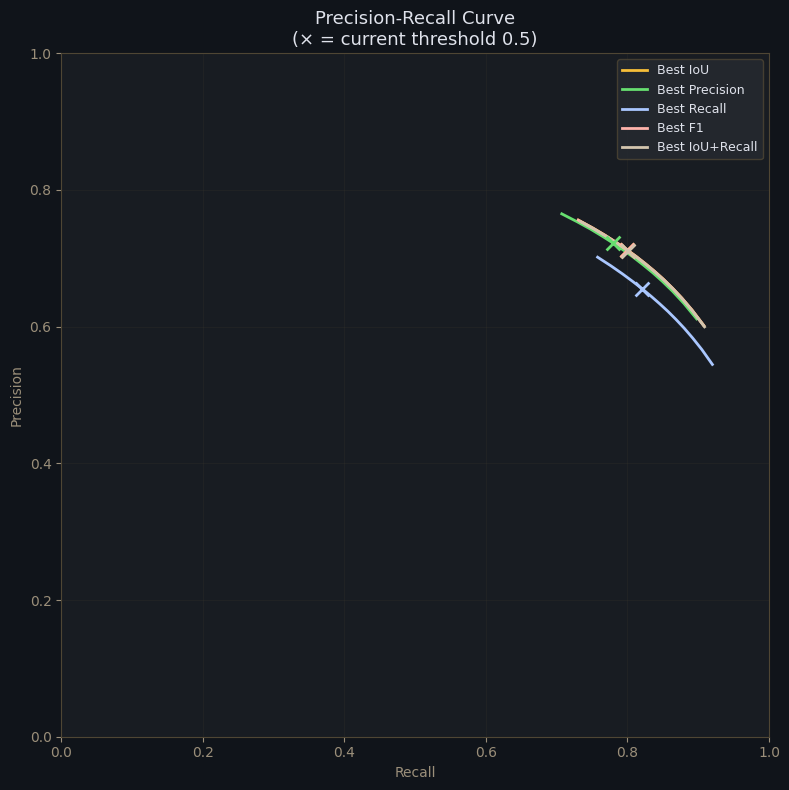

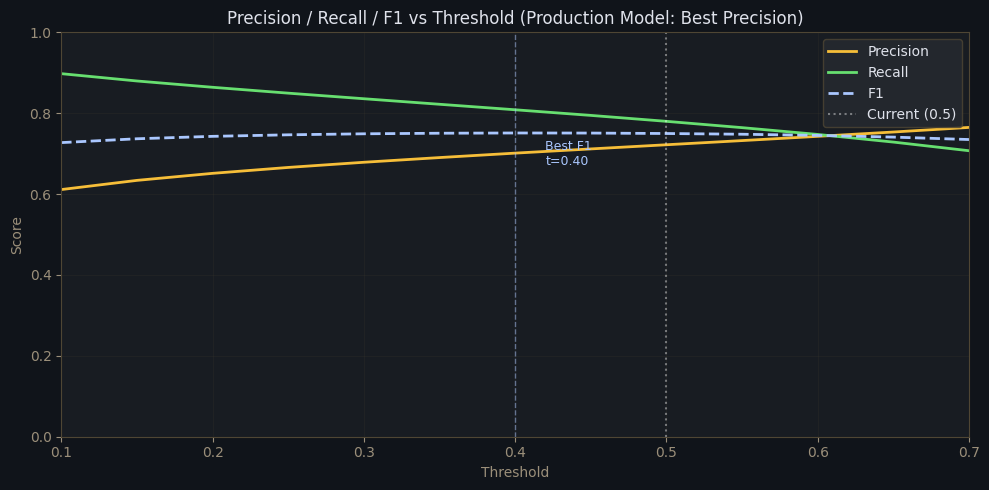

In [ ]:
COLORS = ['#f6be39', '#67df70', '#aac7ff', '#ffb4ab', '#d3c5ae']
OUTPUT_DIR = Path('/content/threshold_sweep_results')
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Plot 1: F1 vs Threshold ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#10141a')
ax.set_facecolor('#181c22')

for (model_name, results), color in zip(all_sweep_results.items(), COLORS):
    ts = [r['threshold'] for r in results]
    f1 = [r['f1'] for r in results]
    best_idx = int(np.argmax(f1))
    ax.plot(ts, f1, color=color, linewidth=2, label=f'{model_name} (best t={ts[best_idx]:.2f}, F1={f1[best_idx]:.3f})')
    ax.axvline(ts[best_idx], color=color, linestyle='--', alpha=0.4, linewidth=1)
    ax.scatter([ts[best_idx]], [f1[best_idx]], color=color, s=80, zorder=5)

ax.axvline(0.5, color='white', linestyle=':', alpha=0.3, linewidth=1.5, label='Current threshold (0.5)')
ax.set_xlabel('Threshold', color='#9b8f7a'); ax.set_ylabel('F1 Score', color='#9b8f7a')
ax.set_title('F1 Score vs Threshold', color='#dfe2eb', fontsize=13)
ax.tick_params(colors='#9b8f7a'); ax.spines[:].set_color('#4f4634')
ax.legend(facecolor='#262a31', edgecolor='#4f4634', labelcolor='#dfe2eb', fontsize=8)
ax.set_xlim(THRESHOLDS[0], THRESHOLDS[-1]); ax.set_ylim(0, 1)
ax.grid(True, alpha=0.15, color='#4f4634')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'f1_vs_threshold.png', dpi=150, bbox_inches='tight', facecolor='#10141a')
plt.show()

# ── Plot 2: IoU vs Threshold ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#10141a'); ax.set_facecolor('#181c22')

for (model_name, results), color in zip(all_sweep_results.items(), COLORS):
    ts  = [r['threshold'] for r in results]
    iou = [r['iou'] for r in results]
    best_idx = int(np.argmax(iou))
    ax.plot(ts, iou, color=color, linewidth=2, label=f'{model_name} (best t={ts[best_idx]:.2f}, IoU={iou[best_idx]:.3f})')
    ax.axvline(ts[best_idx], color=color, linestyle='--', alpha=0.4, linewidth=1)
    ax.scatter([ts[best_idx]], [iou[best_idx]], color=color, s=80, zorder=5)

ax.axvline(0.5, color='white', linestyle=':', alpha=0.3, linewidth=1.5, label='Current threshold (0.5)')
ax.set_xlabel('Threshold', color='#9b8f7a'); ax.set_ylabel('IoU', color='#9b8f7a')
ax.set_title('IoU vs Threshold', color='#dfe2eb', fontsize=13)
ax.tick_params(colors='#9b8f7a'); ax.spines[:].set_color('#4f4634')
ax.legend(facecolor='#262a31', edgecolor='#4f4634', labelcolor='#dfe2eb', fontsize=8)
ax.set_xlim(THRESHOLDS[0], THRESHOLDS[-1]); ax.set_ylim(0, 1)
ax.grid(True, alpha=0.15, color='#4f4634')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'iou_vs_threshold.png', dpi=150, bbox_inches='tight', facecolor='#10141a')
plt.show()

# ── Plot 3: Precision vs Recall (PR curve) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor('#10141a'); ax.set_facecolor('#181c22')

for (model_name, results), color in zip(all_sweep_results.items(), COLORS):
    prec = [r['precision'] for r in results]
    rec  = [r['recall']    for r in results]
    ts   = [r['threshold'] for r in results]
    ax.plot(rec, prec, color=color, linewidth=2, label=model_name)
    # Mark t=0.5
    idx_05 = min(range(len(ts)), key=lambda i: abs(ts[i] - 0.5))
    ax.scatter([rec[idx_05]], [prec[idx_05]], color=color, s=100, marker='x', zorder=5, linewidths=2)

ax.set_xlabel('Recall', color='#9b8f7a'); ax.set_ylabel('Precision', color='#9b8f7a')
ax.set_title('Precision-Recall Curve\n(× = current threshold 0.5)', color='#dfe2eb', fontsize=13)
ax.tick_params(colors='#9b8f7a'); ax.spines[:].set_color('#4f4634')
ax.legend(facecolor='#262a31', edgecolor='#4f4634', labelcolor='#dfe2eb', fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(True, alpha=0.15, color='#4f4634')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'precision_recall_curve.png', dpi=150, bbox_inches='tight', facecolor='#10141a')
plt.show()

# ── Plot 4: Precision & Recall vs Threshold (Best Precision model only) ────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#10141a'); ax.set_facecolor('#181c22')

prod_results = all_sweep_results.get('Best Precision', list(all_sweep_results.values())[0])
ts   = [r['threshold'] for r in prod_results]
prec = [r['precision'] for r in prod_results]
rec  = [r['recall']    for r in prod_results]
f1   = [r['f1']        for r in prod_results]

ax.plot(ts, prec, color='#f6be39', linewidth=2, label='Precision')
ax.plot(ts, rec,  color='#67df70', linewidth=2, label='Recall')
ax.plot(ts, f1,   color='#aac7ff', linewidth=2, label='F1', linestyle='--')
ax.axvline(0.5, color='white', linestyle=':', alpha=0.4, linewidth=1.5, label='Current (0.5)')

best_f1_idx = int(np.argmax(f1))
ax.axvline(ts[best_f1_idx], color='#aac7ff', linestyle='--', alpha=0.5, linewidth=1)
ax.annotate(f'Best F1\nt={ts[best_f1_idx]:.2f}', xy=(ts[best_f1_idx], f1[best_f1_idx]),
            xytext=(ts[best_f1_idx]+0.02, f1[best_f1_idx]-0.08),
            color='#aac7ff', fontsize=9)

ax.set_xlabel('Threshold', color='#9b8f7a'); ax.set_ylabel('Score', color='#9b8f7a')
ax.set_title('Precision / Recall / F1 vs Threshold (Production Model: Best Precision)', color='#dfe2eb', fontsize=12)
ax.tick_params(colors='#9b8f7a'); ax.spines[:].set_color('#4f4634')
ax.legend(facecolor='#262a31', edgecolor='#4f4634', labelcolor='#dfe2eb')
ax.set_xlim(THRESHOLDS[0], THRESHOLDS[-1]); ax.set_ylim(0, 1)
ax.grid(True, alpha=0.15, color='#4f4634')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prod_model_detail.png', dpi=150, bbox_inches='tight', facecolor='#10141a')
plt.show()

## Summary table + recommendation

In [ ]:
print('THRESHOLD SWEEP SUMMARY')
print('=' * 80)
print(f'{"Model":<30} {"Best F1":>10} {"@ Thresh":>10} {"Precision":>10} {"Recall":>10} {"IoU":>8}')
print('-' * 80)

recommendations = []
for model_name, results in all_sweep_results.items():
    best = max(results, key=lambda r: r['f1'])
    print(f'{model_name:<30} {best["f1"]:>10.4f} {best["threshold"]:>10.2f} '
          f'{best["precision"]:>10.4f} {best["recall"]:>10.4f} {best["iou"]:>8.4f}')
    recommendations.append((model_name, best))

# Current production performance (Best Precision @ 0.5)
print('\nCURRENT PRODUCTION (Best Precision model @ threshold=0.5)')
print('-' * 80)
prod = all_sweep_results.get('Best Precision', list(all_sweep_results.values())[0])
curr = next(r for r in prod if abs(r['threshold'] - 0.5) < 0.01)
print(f'  Precision: {curr["precision"]:.4f}  Recall: {curr["recall"]:.4f}  '
      f'F1: {curr["f1"]:.4f}  IoU: {curr["iou"]:.4f}')

# Recommendation
best_overall = max(recommendations, key=lambda x: x[1]['f1'])
print(f'\nRECOMMENDATION')
print('-' * 80)
print(f'  Best model:    {best_overall[0]}')
print(f'  Best threshold: {best_overall[1]["threshold"]}')
print(f'  Expected F1:   {best_overall[1]["f1"]:.4f}')
print(f'  Expected IoU:  {best_overall[1]["iou"]:.4f}')
print(f'\n  To apply: set THRESHOLD={best_overall[1]["threshold"]} in production config')

# Save results JSON
with open(OUTPUT_DIR / 'sweep_results.json', 'w') as f:
    json.dump(all_sweep_results, f, indent=2)
print(f'\nResults saved to {OUTPUT_DIR}')

THRESHOLD SWEEP SUMMARY
Model                             Best F1   @ Thresh  Precision     Recall      IoU
--------------------------------------------------------------------------------
Best IoU                           0.7534       0.45     0.7023     0.8126   0.6044
Best Precision                     0.7511       0.40     0.7013     0.8085   0.6014
Best Recall                        0.7304       0.60     0.6769     0.7932   0.5754
Best F1                            0.7534       0.45     0.7023     0.8126   0.6044
Best IoU+Recall                    0.7531       0.50     0.7102     0.8014   0.6039

CURRENT PRODUCTION (Best Precision model @ threshold=0.5)
--------------------------------------------------------------------------------
  Precision: 0.7220  Recall: 0.7799  F1: 0.7498  IoU: 0.5998

RECOMMENDATION
--------------------------------------------------------------------------------
  Best model:    Best IoU
  Best threshold: 0.45
  Expected F1:   0.7534
  Expected IoU:  0.6

## Sync results to GCS

In [ ]:
subprocess.run(['gsutil', '-m', 'rsync', '-r', str(OUTPUT_DIR), BUCKET_RESULTS])
print(f'Results synced to {BUCKET_RESULTS}')

Results synced to gs://mcnobert-optical-data/threshold_sweep_results
